##Enviorment
(1) Packages

In [2]:
%%capture
! pip install langchain_community tiktoken langchain-openai langchainhub chromadb langchain langchain_groq

##Tracing:
Optionally, use LangSmith for tracing (shown at bottom) by setting:

In [27]:
from google.colab import userdata
import os

os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ["LANGCHAIN_PROJECT"] = "Query Transformation"

##Question ⇒ LLM ⇒ Reshape, Breakdown, Abstract, Convert to Hypothetical Documents

- Reshape: Reformulate query for clarity.

- Breakdown: Split complex questions into sub-queries.

- Abstract: Extract core information need.

- Hypothetical Docs: Generate synthetic documents to guide retrieval.

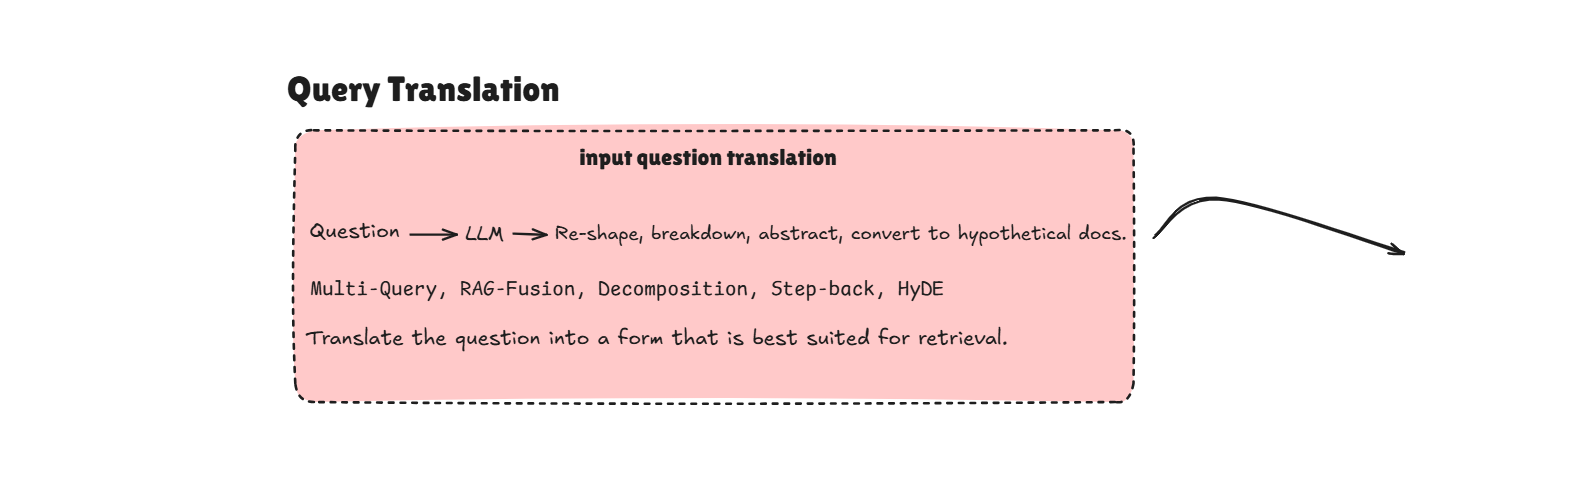

In [ ]:
display(Image("/content/Screenshot 2025-09-04 124037.png"))

##Part 1: Multi Query
- Split a single query into multiple related sub-queries.

- Ensures comprehensive coverage of all aspects of a question.

In [28]:
# Imports
import os
import bs4
from langchain import hub
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_groq import ChatGroq
from langchain_community.embeddings import SentenceTransformerEmbeddings
from google.colab import userdata # Import userdata
from langchain.prompts import ChatPromptTemplate
from langchain.load import dumps, loads

# for snaps
from IPython.display import Image, display

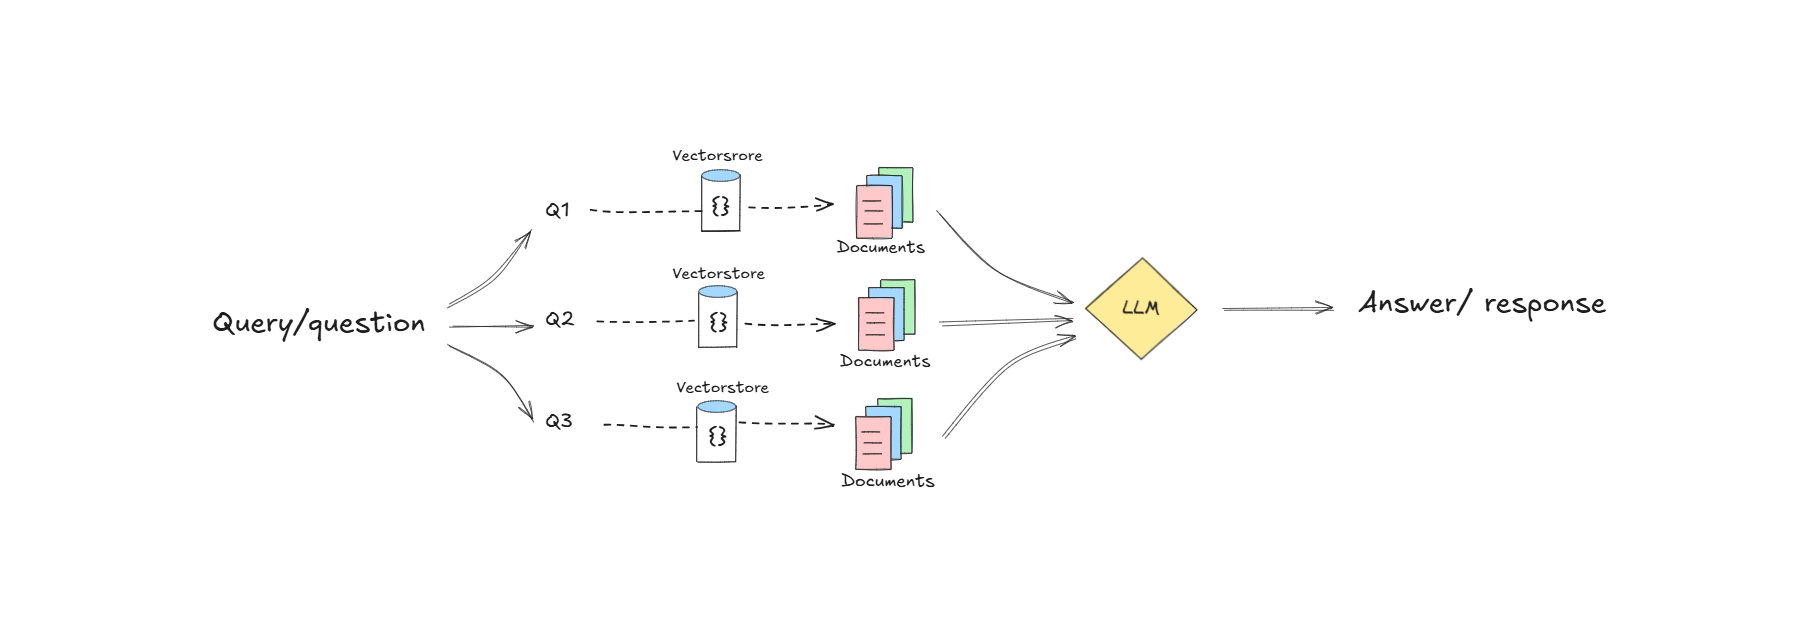

In [ ]:
display(Image("/content/Screenshot 2025-09-04 100430.png"))

Docs:
 * https://python.langchain.com/docs/how_to/MultiQueryRetriever

##Index:

In [29]:
##INDEXING + RETRIEVAL with Groq ####

# Load Documents
loader = WebBaseLoader(
    web_paths=["https://lilianweng.github.io/posts/2023-06-23-agent/"],
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

# Split into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200
)

# Make splits
splits = text_splitter.split_documents(docs)

# Embed and store in vector DB
# Instantiate your embedding function here
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings # <- Replace None with your instantiated embedding function
)

# Retriever
retriever = vectorstore.as_retriever()

###Prompt

In [30]:
template = """You are an AI language model assistant.
Your task is to generate five alternative versions of the given user question
to help retrieve relevant documents from a vector database.
By generating multiple perspectives on the question, your goal is to overcome
some of the limitations of distance-based similarity search.

Return exactly five alternative questions, each on its own line.

Original question: {question}
"""

In [31]:
prompt_perspectives = ChatPromptTemplate.from_template(template)

In [32]:
# LLM (Groq)
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
    model="moonshotai/kimi-k2-instruct-0905", # you can switch to other Groq-supported models
    temperature=0)

In [33]:
# Chain
generate_queries = (prompt_perspectives
                   | llm
                   | StrOutputParser()
                   | (lambda x: x.split("\n"))
                   )

In [34]:
def get_unique_union(documents: list[list]):
    """ Unique union of retrieved docs """
    # Flatten list of lists, and convert each Document to string
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]
    # Get unique documents
    unique_docs = list(set(flattened_docs))
    # Return
    return [loads(doc) for doc in unique_docs]

# Retrieve
question = "What is task decomposition for LLM agents?"
retrieval_chain = generate_queries | retriever.map() | get_unique_union
docs = retrieval_chain.invoke({"question":question})
len(docs)

5

In [35]:
from operator import itemgetter

# Prompt
template = """Answer the question based on the following context:
{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

# LLM (Groq)
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),
    model="moonshotai/kimi-k2-instruct-0905",
    temperature=0
)

# Corrected final_chain
final_chain = (
    {
        "context": generate_queries #context creation

        | retriever.map()
        | get_unique_union
        | (lambda docs: "\n\n".join([doc.page_content for doc in docs])),

        "question": itemgetter("question") #just pass the question along
    }

    | prompt
    | llm
    | StrOutputParser()
)

final_chain.invoke({"question":question})

'Task decomposition for LLM agents is the process of breaking a large, complex task into smaller, manageable sub-goals or steps. This can be done by prompting the LLM with phrases like “Steps for XYZ.\\n1.” or “What are the subgoals for achieving XYZ?”, by using task-specific instructions, or with human input.'

##Part 2: Rag - Fusion

- Combine retrieved documents and LLM generation.

- Produces contextually rich, evidence-grounded answers.

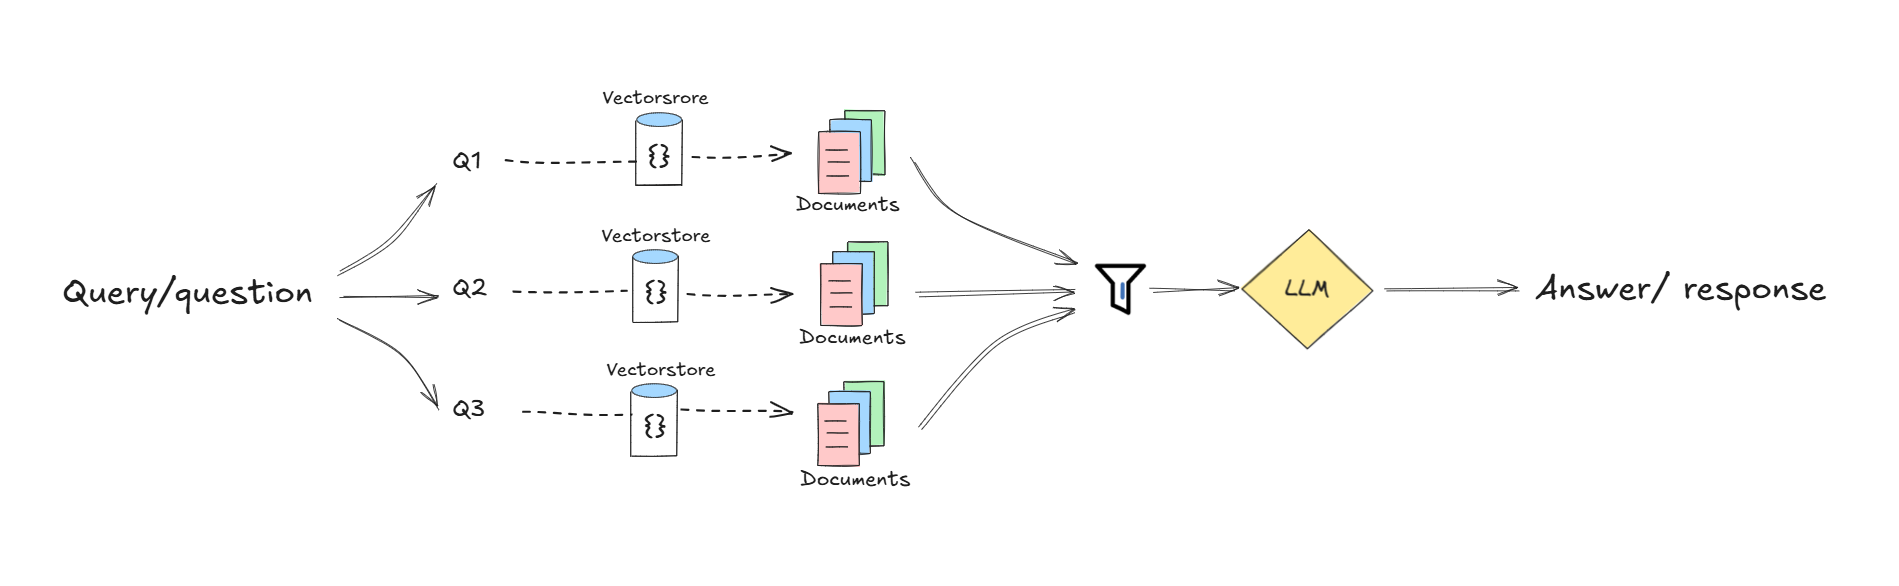

In [ ]:
display(Image("/content/Screenshot 2025-09-04 101824.png"))

Docs:
 - https://github.com/langchain-ai/langchain/blob/master/cookbook/rag_fusion.ipynb?ref=blog.langchain.dev

Blog / repo:
 - https://towardsdatascience.com/forget-rag-the-future-is-rag-fusion-1147298d8ad1

###Prompt

In [36]:
from langchain.prompts import ChatPromptTemplate

# RAG-Fusion: Related
template = """You are a helpful assistant that generates multiple search queries based on a single input query. \n
Generate multiple search queries related to: {question} \n
Output (4 queries):"""
prompt_rag_fusion = ChatPromptTemplate.from_template(template)

In [37]:
# LLM (Groq)
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
    model="moonshotai/kimi-k2-instruct-0905", # you can switch to other Groq-supported models
    temperature=0)

# Chain
generate_queries = (prompt_rag_fusion
                   | llm
                   | StrOutputParser()
                   | (lambda x: x.split("\n"))
                   )

In [38]:
def reciprocal_rank_fusion(results: list[list], k=60):
    """ Reciprocal_rank_fusion that takes multiple lists of ranked documents
        and an optional parameter k used in the RRF formula """

    # Initialize a dictionary to hold fused scores for each unique document
    fused_scores = {}

    # Iterate through each list of ranked documents
    for docs in results:
        # Iterate through each document in the list, with its rank (position in the list)
        for rank, doc in enumerate(docs):
            # Convert the document to a string format to use as a key (assumes documents can be serialized to JSON)
            doc_str = dumps(doc)
            # If the document is not yet in the fused_scores dictionary, add it with an initial score of 0
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            # Retrieve the current score of the document, if any
            previous_score = fused_scores[doc_str]
            # Update the score of the document using the RRF formula: 1 / (rank + k)
            fused_scores[doc_str] += 1 / (rank + k)

    # Sort the documents based on their fused scores in descending order to get the final reranked results
    reranked_results = [
        (loads(doc), score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]

    # Return the reranked results as a list of tuples, each containing the document and its fused score
    return reranked_results

retrieval_chain_rag_fusion = generate_queries | retriever.map() | reciprocal_rank_fusion
docs = retrieval_chain_rag_fusion.invoke({"question": question})
len(docs)

4

In [39]:
from langchain_core.runnables import RunnablePassthrough

# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    {"context": retrieval_chain_rag_fusion,
     "question": itemgetter("question")}
    | prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"question":question})

'Task decomposition for LLM agents is the process of breaking a large, complex task into smaller, manageable sub-goals.  \nIt can be done in three main ways:\n\n1. Simple LLM prompting – e.g., asking the model “Steps for XYZ” or “What are the sub-goals for achieving XYZ?”  \n2. Task-specific instructions – e.g., “Write a story outline” when writing a novel.  \n3. Human input – letting a person supply the breakdown.'

###Part 3: Decomposition

- Break complex queries into simpler, manageable parts.

- Allows independent retrieval and later recombination of answers.

Paper:
[Least to Most Prompting](https://arxiv.org/pdf/2205.10625)

In [40]:
# Decomposition
template = """You are a helpful assistant that generates multiple sub-questions related to an input question. \n
The goal is to break down the input into a set of sub-problems / sub-questions that can be answers in isolation. \n
Generate multiple search queries related to: {question} \n
Output (3 queries):"""
prompt_decomposition = ChatPromptTemplate.from_template(template)

In [41]:
# LLM (Groq)
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
    model="moonshotai/kimi-k2-instruct", # you can switch to other Groq-supported models
    temperature=0)

# Chain
generate_queries_decomposition = (prompt_decomposition
                   | llm
                   | StrOutputParser()
                   | (lambda x: x.split("\n"))
                   )

#Run
question = "What are the main components of an LLM-powered autonomous agent system?"
questions = generate_queries_decomposition.invoke({"question":question})

In [42]:
questions

['1. What are the core modules (e.g., prompt template, memory store, planner, tool-caller) inside an LLM-based autonomous agent?  ',
 '2. How do memory mechanisms (short-term vs. long-term, vector DB, context window) function in LLM agents?  ',
 '3. Which tool-integration patterns (API wrappers, function-calling, code execution sandboxes) do LLM agents use for external actions?']

##Answer Recursively:
- Process queries or sub-queries in a recursive manner.

- For complex questions, break them into smaller parts and solve each part individually.

- Combine answers from sub-queries to form the final response.

- Useful in multi-step reasoning, decomposition, and iterative retrieval.

- Ensures completeness and handles dependencies between query parts efficiently.



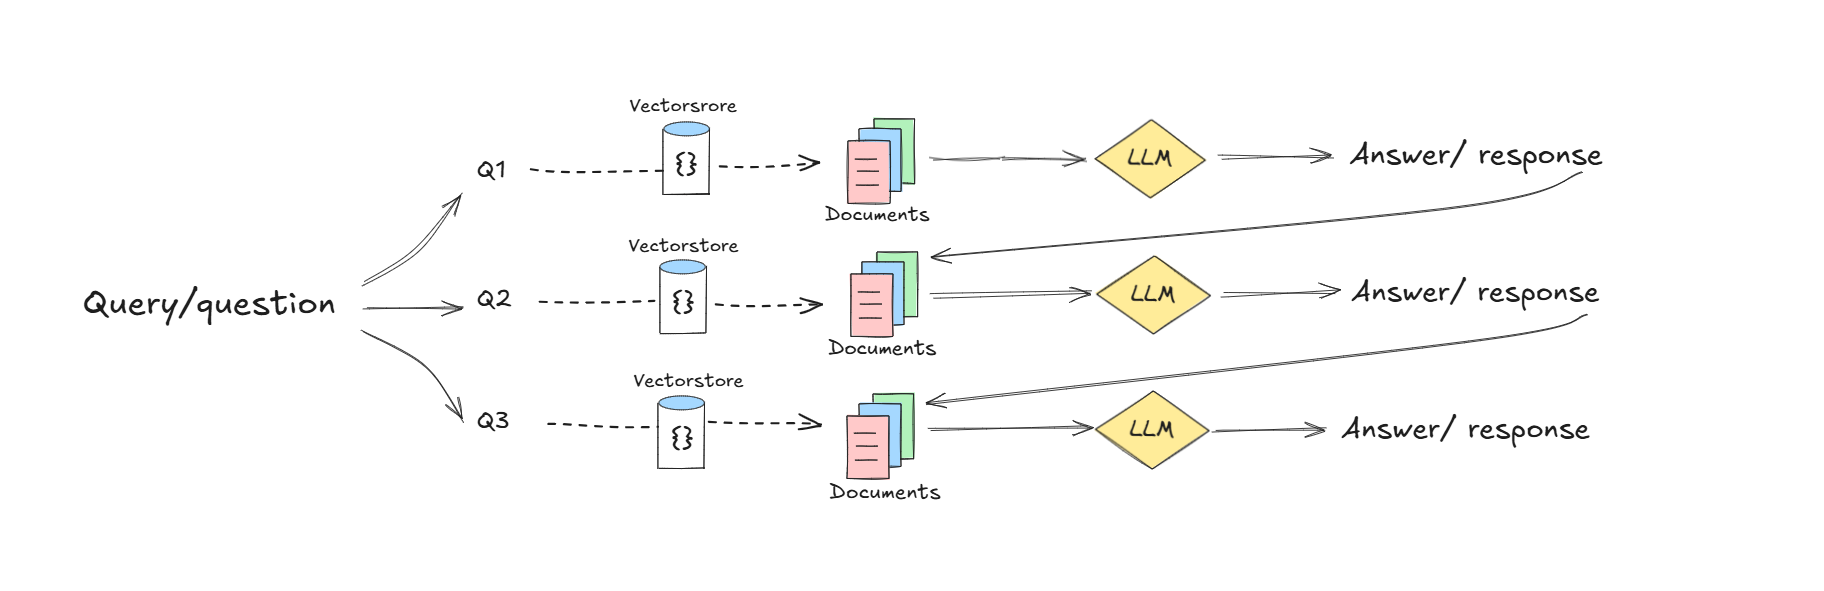

In [ ]:
display(Image("/content/Screenshot 2025-09-04 103548.png"))

Papers:

* https://arxiv.org/pdf/2205.10625.pdf
* https://arxiv.org/abs/2212.10509.pdf

In [43]:
# Prompt
template = """Here is the question you need to answer:

\n --- \n {question} \n --- \n

Here is any available background question + answer pairs:

\n --- \n {q_a_pairs} \n --- \n

Here is additional context relevant to the question:

\n --- \n {context} \n --- \n

Use the above context and any background question + answer pairs to answer the question: \n {question}
"""

decomposition_prompt = ChatPromptTemplate.from_template(template)

In [44]:
def format_qa_pair(question, answer):
    """Format Q and A pair"""

    formatted_string = ""
    formatted_string += f"Question: {question}\nAnswer: {answer}\n\n"
    return formatted_string.strip()

In [45]:
# LLM (Groq)
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
    model="moonshotai/kimi-k2-instruct", # you can switch to other Groq-supported models
    temperature=0)

In [46]:
q_a_pairs = ""
for q in questions:

    rag_chain = (
    {"context": itemgetter("question") | retriever,
     "question": itemgetter("question"),
     "q_a_pairs": itemgetter("q_a_pairs")}
    | decomposition_prompt
    | llm
    | StrOutputParser())

    answer = rag_chain.invoke({"question":q,"q_a_pairs":q_a_pairs})
    q_a_pair = format_qa_pair(q,answer)
    q_a_pairs = q_a_pairs + "\n---\n"+  q_a_pair

In [47]:
answer

'LLM agents rely on three dominant tool-integration patterns to act outside their own weights:\n\n1. API wrappers / Plugins  \n   The agent emits a special token or JSON blob that the surrounding wrapper recognises as a request to call an external REST endpoint.  \n   – ChatGPT Plugins, OpenAI’s “function calling” and TALM/Toolformer all follow this pattern: the model only decides which API to invoke and with what arguments; the wrapper performs the HTTP request and returns the result to the prompt.  \n   – HuggingGPT extends this idea by letting the wrapper invoke HuggingFace models as if they were tools.\n\n2. Function-calling DSL inside the prompt  \n   Instead of raw HTTP, the agent is taught a miniature domain-specific language (DSL) that maps natural-language intents to pre-defined host-side functions.  \n   – The LLM outputs something like `CALC(3+5)` or `SEARCH("weather in Paris")`; an external interpreter parses the DSL and executes the corresponding function, then feeds the t

In [48]:
# Answer each sub-question individually
# RAG prompt
prompt_rag = hub.pull("rlm/rag-prompt")

def retrieve_and_rag(question,prompt_rag,sub_question_generator_chain):
    """RAG on each sub-question"""

    # Use our decomposition /
    sub_questions = sub_question_generator_chain.invoke({"question":question})

    # Initialize a list to hold RAG chain results
    rag_results = []

    for sub_question in sub_questions:

        # Retrieve documents for each sub-question
        retrieved_docs = retriever.get_relevant_documents(sub_question)

        # Use retrieved documents and sub-question in RAG chain
        answer = (prompt_rag | llm | StrOutputParser()).invoke({"context": retrieved_docs,
                                                                "question": sub_question})
        rag_results.append(answer)

    return rag_results,sub_questions

# Wrap the retrieval and RAG process in a RunnableLambda for integration into a chain
answers, questions = retrieve_and_rag(question, prompt_rag, generate_queries_decomposition)

/tmp/ipython-input-2421192774.py:17: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieved_docs = retriever.get_relevant_documents(sub_question)


In [49]:
def format_qa_pairs(questions, answers):
    """Format Q and A pairs"""

    formatted_string = ""
    for i, (question, answer) in enumerate(zip(questions, answers), start=1):
        formatted_string += f"Question {i}: {question}\nAnswer {i}: {answer}\n\n"
    return formatted_string.strip()

context = format_qa_pairs(questions, answers)

# Prompt
template = """Here is a set of Q+A pairs:

{context}

Use these to synthesize an answer to the question: {question}
"""

In [50]:
# LLM (Groq)
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
    model="moonshotai/kimi-k2-instruct", # you can switch to other Groq-supported models
    temperature=0)

In [51]:
final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
)
final_rag_chain.invoke({"context":context,"question":question})

'The main components are:\n\n1. Planning – breaks the objective into sub-goals and performs self-reflection.  \n2. Memory – short-term (in-context) plus long-term (external vector store).  \n3. Tool use – invokes external APIs through wrappers, function-calling, or API search engines.'

##Answer Individually

- Treat each sub-query or decomposed question separately.

- Retrieve and generate answers independently for each part.

- Avoids interference between different aspects of a complex query.

- Final response can be assembled by combining individual answers.

- Ensures clarity and accuracy for multi-faceted questions.

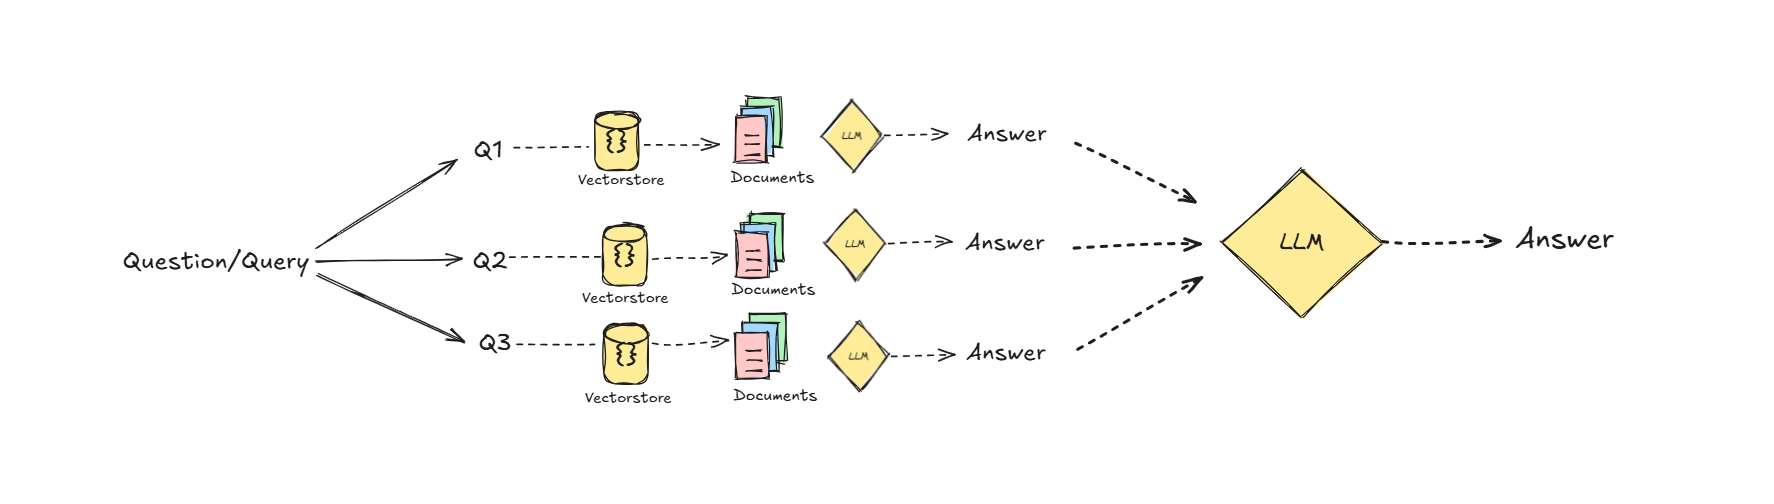

In [ ]:
display(Image("/content/Screenshot 2025-09-05 115653.png"))

In [52]:
# Answer each sub-question or query individually
from langchain import hub
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq

In [53]:
# RAG prompt
prompt_rag = hub.pull("rlm/rag-prompt")

In [54]:
def retrieve_and_rag(question,prompt_rag,sub_question_generator_chain):
    """RAG on each sub-question"""

    # Use our decomposition /
    sub_questions = sub_question_generator_chain.invoke({"question":question})

    # Initialize a list to hold RAG chain results
    rag_results = []

    for sub_question in sub_questions:

        # Retrieve documents for each sub-question
        retrieved_docs = retriever.get_relevant_documents(sub_question)

        # Use retrieved documents and sub-question in RAG chain
        answer = (prompt_rag
                  | llm
                  | StrOutputParser()).invoke({"context": retrieved_docs,
                                                                "question": sub_question})
        rag_results.append(answer)

    return rag_results,sub_questions

In [55]:
# Wrap the retrieval and RAG process in a RunnableLambda for integration into a chain
answers, questions = retrieve_and_rag(question, prompt_rag, generate_queries_decomposition)

In [56]:
def format_qa_pairs(questions, answers):
    """Format Q and A pairs"""

    formatted_string = ""
    for i, (question, answer) in enumerate(zip(questions, answers), start=1):
        formatted_string += f"Question {i}: {question}\nAnswer {i}: {answer}\n\n"
    return formatted_string.strip()

context = format_qa_pairs(questions, answers)

# Prompt
template = """Here is a set of Q+A pairs:

{context}

Use these to synthesize an answer to the question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
    | (lambda x: x.split("\n"))
)

final_rag_chain.invoke({"context":context,"question":question})

['An LLM-powered autonomous agent is usually built from three tightly-coupled sub-systems:',
 '',
 '1. Planning & Reasoning  ',
 '   A controller that repeatedly (a) decomposes the user objective into short-lived sub-goals, (b) chooses the next atomic action, and (c) reflects on the result and refines the plan.  ',
 '   Implementation: prompt-based chain-of-thought, ReAct loops, or classical planners wrapped by the LLM.',
 '',
 '2. Memory Layer  ',
 '   - Short-term: the LLM’s context window that holds the working memory for the current reasoning step.  ',
 '   - Long-term: an external vector database that stores prior conversations, facts, and tool results; retrieved context is injected back into the prompt to extend retention beyond the context length.',
 '',
 '3. Tool & Action Interface  ',
 '   The agent calls external utilities through API wrappers (OpenAI function-calling, ChatGPT Plugins, Toolformer, TALM, API-Bank, etc.).  ',
 '   Retrieved outputs are fed back to the planner, 

##Part 3: Step Back

- Revisit and refine queries or intermediate answers.

- Improves retrieval relevance and completeness iteratively.


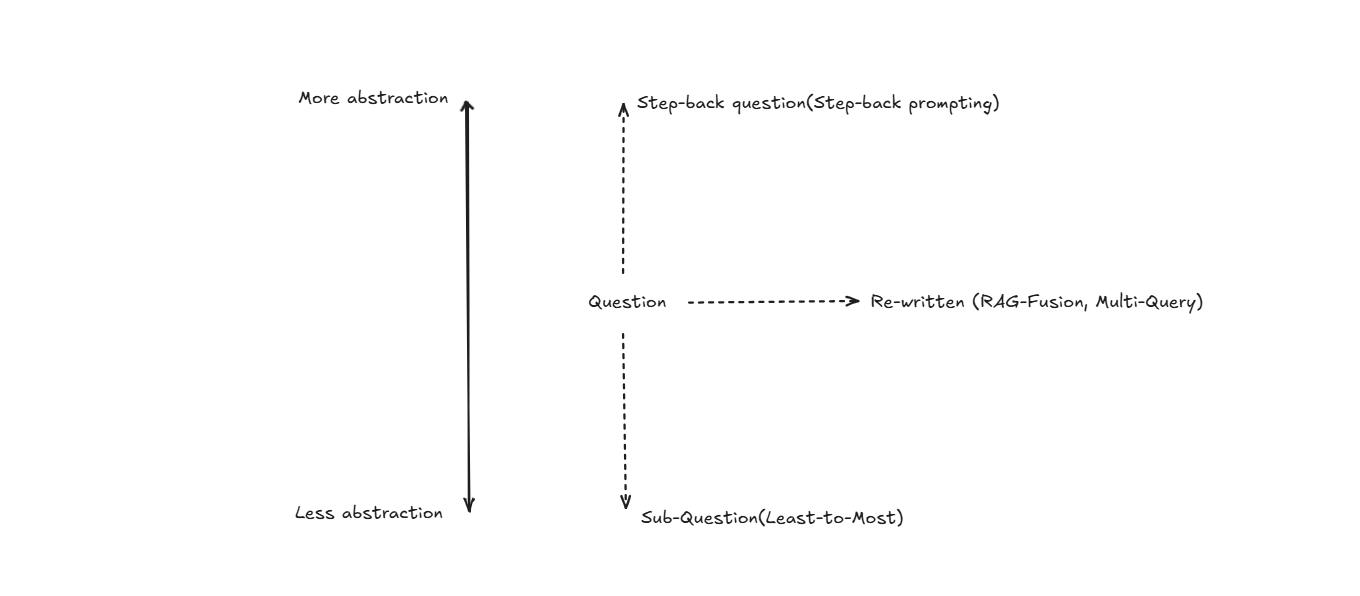

In [ ]:
display(Image("/content/Screenshot 2025-09-04 112730.png"))

Paper:

 * https://arxiv.org/pdf/2310.06117.pdf

In [57]:
# Few Shot Examples
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate
examples = [
    {
        "input": "Could the members of The Police perform lawful arrests?",
        "output": "what can the members of The Police do?",
    },
    {
        "input": "Jan Sindel’s was born in what country?",
        "output": "what is Jan Sindel’s personal history?",
    },
]
# We now transform these to example messages
example_prompt = ChatPromptTemplate.from_messages(
    [
        ("human", "{input}"),
        ("ai", "{output}"),
    ]
)
few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples=examples,
)
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are an expert at world knowledge. Your task is to step back and paraphrase a question to a more generic step-back question, which is easier to answer. Here are a few examples:""",
        ),
        # Few shot examples
        few_shot_prompt,
        # New question
        ("user", "{question}"),

    ]
)

In [58]:
generate_queries_step_back = prompt | llm.bind(temperature=0) | StrOutputParser()
question = "What is task decomposition for LLM agents?"
generate_queries_step_back.invoke({"question": question})

'what are the basic steps involved in decomposing a complex goal into smaller, manageable sub-tasks when designing an AI agent?'

In [59]:
# Response prompt
response_prompt_template = """You are an expert of world knowledge. I am going to ask you a question. Your response should be comprehensive and not contradicted with the following context if they are relevant. Otherwise, ignore them if they are not relevant.

# {normal_context}
# {step_back_context}

# Original Question: {question}
# Answer:"""
response_prompt = ChatPromptTemplate.from_template(response_prompt_template)

chain = (
    {
        # Retrieve context using the normal question
        "normal_context": RunnableLambda(lambda x: x["question"]) | retriever,
        # Retrieve context using the step-back question
        "step_back_context": generate_queries_step_back | retriever,
        # Pass on the question
        "question": lambda x: x["question"],
    }
    | response_prompt
    | llm.bind(temperature=0)
    | StrOutputParser()
    | (lambda x: x.split("\n"))
)

chain.invoke({"question": question})

['Task decomposition for LLM agents is the process of breaking a large, complex objective into smaller, ordered sub-tasks so the agent can tackle them one-by-one instead of trying to solve everything at once.  ',
 'In practice the agent (or the human) can generate this breakdown in three main ways:',
 '',
 '1. Pure LLM prompting – asking the model with phrases like “Steps for XYZ: 1.” or “What are the sub-goals for achieving XYZ?” and letting it emit a numbered list.  ',
 '2. Task-specific templates – supplying a domain prompt such as “Write a story outline.” when the goal is to write a novel; the template nudges the LLM to produce the standard sub-tasks of that domain.  ',
 '3. Human in the loop – letting a person supply or edit the sub-goal list.',
 '',
 'A more recent variant, LLM+P, off-loads the decomposition to an external classical planner: the LLM first translates the problem into PDDL, a classical planner produces the step sequence, and the LLM translates that plan back into n

##Par 4: HydE (Hypothetical Document Embeddings)
- Convert queries into embeddings from hypothetical documents.

- Helps retrieve semantically closest real documents to match intent.

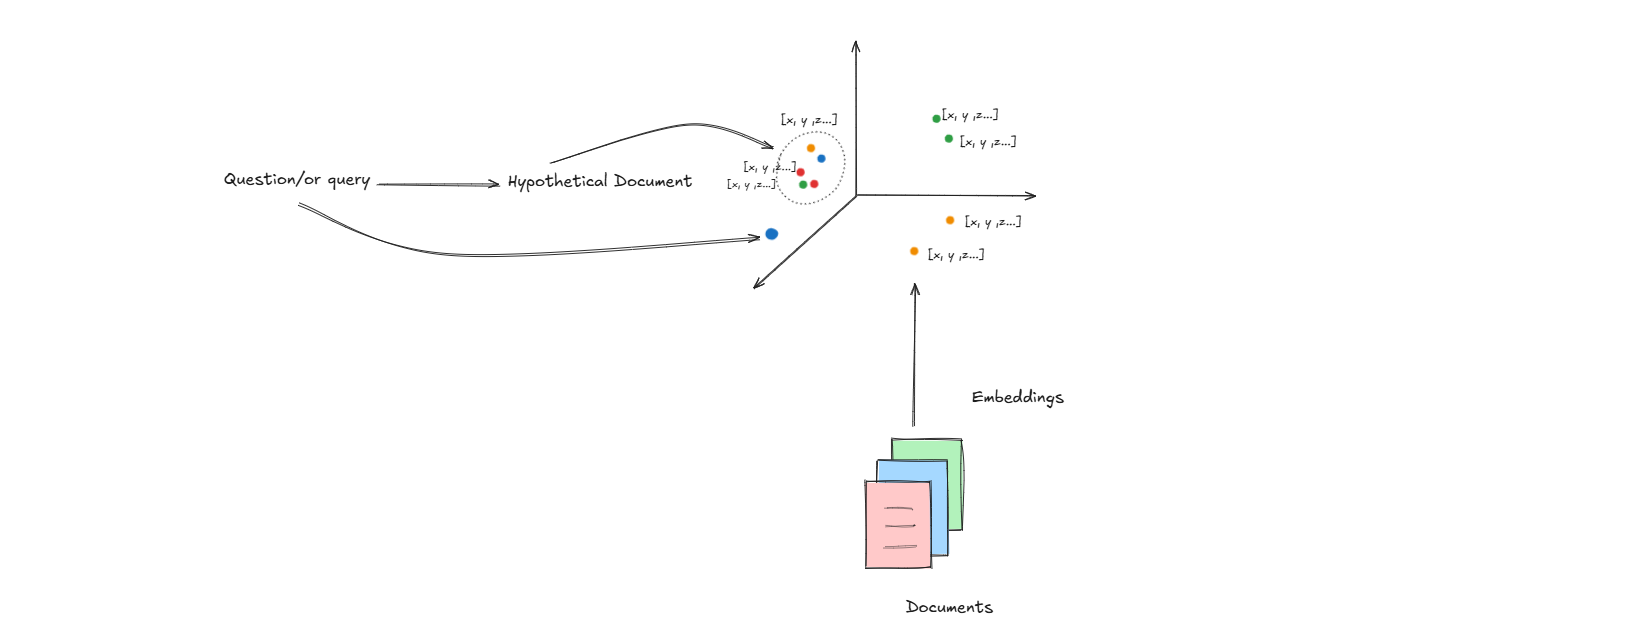

In [ ]:
display(Image("/content/Screenshot 2025-09-04 120533.png"))

In [60]:
from langchain.prompts import ChatPromptTemplate

# HyDE document genration
template = """Please write a scientific paper passage to answer the question
Question: {question}
Passage:"""
prompt_hyde = ChatPromptTemplate.from_template(template)

generate_docs_for_retrieval = (
    prompt_hyde | llm.bind(temperature=0) | StrOutputParser()
)

# Run
question = "What is task decomposition for LLM agents?"
generate_docs_for_retrieval.invoke({"question":question})

'Task decomposition for large-language-model (LLM) agents is the algorithmic process of converting a high-level objective expressed in natural language into a directed acyclic graph (DAG) of tractable, context-bounded sub-tasks that can be solved sequentially or in parallel by the same or specialized sub-models. Formally, given a goal g drawn from the set of all natural-language instructions G, decomposition seeks a tuple D(g)=⟨T,E⟩ where T={t1,…,tn} is a minimal set of sub-tasks and E⊆T×T encodes precedence constraints. Each ti is associated with a specification consisting of (1) a prompt fragment pi, (2) a maximum token budget bi, and (3) a success predicate φi mapping the agent’s output to {0,1}. Decomposition is typically performed by prompting the LLM with meta-instructions such as “generate a checklist for accomplishing ⟨g⟩” or by invoking a smaller planner model fθ trained to maximize the expected fraction of sub-tasks whose φi evaluates to 1 while minimizing ∑ibi. Empirically, 

In [61]:
# Retrieve
retrieval_chain = generate_docs_for_retrieval | retriever
retireved_docs = retrieval_chain.invoke({"question":question})
retireved_docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\nAnother quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. This approach utilizes the Planning Domain Definition Language (PDDL) as an intermediate interface to describe the planning problem. In this process, LLM (1) translates the problem into “Problem PDDL”, then (2) requests a classical planner to generate a PDDL plan based on an existing “Domain PDDL”, and finally (3) translates the PDDL plan back into natural language. Essentially, the planning step is outsourced to an external tool, assuming the availability of domain-specific PDDL and a suitable planner

In [63]:
# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
    | (lambda x: x.split("\n"))
)

final_rag_chain.invoke({"context":retireved_docs,"question":question})

['Task decomposition for LLM agents is the process of breaking a complex goal into smaller, manageable sub-tasks.  ',
 'It can be done in three main ways:  ',
 '1. Prompting the LLM with simple cues like “Steps for XYZ” or “What are the subgoals for achieving XYZ?”  ',
 '2. Giving task-specific instructions (e.g., “Write a story outline.” for a novel).  ',
 '3. Incorporating human input.']

Trace:
https://smith.langchain.com/public/66992097-52d8-4fc2-a7a9-5a29ae01ff03/r